In [2]:
from pyfaidx import Fasta

In [3]:
import h5py
h5f = "results/chrombpnet/ATAC_PE/GM12878/nautilus_runs/GM12878_03.01.2022_bias_128_4_1234_0.4_fold_0/chrombpnet_model/chrombpnet_wo_bias_predictions.h5"
f1 = h5py.File(h5f,'r+')    
f1

<HDF5 file "chrombpnet_wo_bias_predictions.h5" (mode r+)>

In [5]:
f1.keys()

<KeysViewHDF5 ['coords', 'predictions']>

In [10]:
f1['coords']['coords_center'][0:3]

array([100026350, 100027872, 100033601])

In [12]:
f1['coords']['coords_chrom'][0:3]

array([b'chr1', b'chr1', b'chr1'], dtype=object)

In [13]:
f1['coords']['coords_center'][0:3]

array([100026350, 100027872, 100033601])

In [15]:
f1['predictions'].keys()

<KeysViewHDF5 ['logcounts', 'profs']>

In [17]:
f1['predictions']["logcounts"][0:3]

array([5.89502001, 7.08187771, 5.20790577])

In [26]:
sum(f1['predictions']["profs"][0:1,:][0])

0.9999999974097591

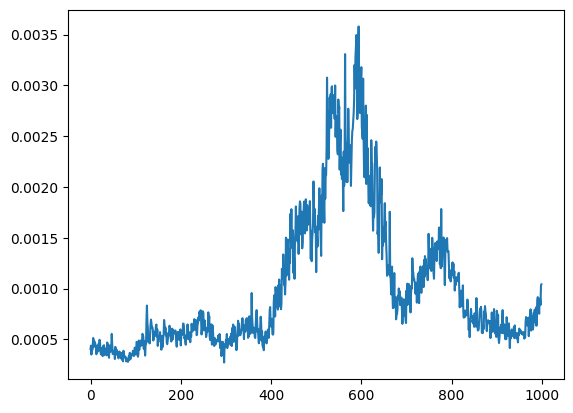

In [35]:
import matplotlib.pyplot as plt

plt.plot(f1['predictions']["profs"][0:1,:][0])

In [33]:
coordinates = [['chr1', 100026350+1057, 'seq1'], ['chr1', 100027872+1057, 'seq2']]

genome_fa="reference/hg38.genome.fa"

def fetch_and_write_sequences(coords, genome_fa, out_fasta_path, flank):
    fasta = Fasta(genome_fa)
    with open(out_fasta_path, "w") as out_f:
        for chrom, center, name in coords:
            start = center - flank
            end = center + flank
            seq = fasta[chrom][start:end].seq.upper()
            out_f.write(f">{name}\n{seq}\n")

    print(f"Sequences written to {out_fasta_path}")


fetch_and_write_sequences(coordinates, genome_fa, out_fasta_path="example.fa", flank=2114//2)

Sequences written to example.fa


In [39]:
100026350+1057-1057

100026350

In [38]:
100026350+1057-1057+2114

100028464

In [41]:
100026350+1057+165

100027572

In [43]:
100026350+1057-1057+1057+165


100027572

In [44]:
100026350+1057

100027407

In [45]:
100027407+165


100027572

In [46]:
27473-27407

66